# Pokemon Data Analysis

For Applied AI

Created by Group Vinland:
- Hertz Lenin C. Miscreola
- Veneerick Joel C. Ondon



## 1. Setup

Run `python -m pip install pandas numpy seaborn matplotlib scikit-learn statsmodels mlxtend`

In [ ]:
import os

import numpy as np

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA
from sklearn.preprocessing import  StandardScaler

In [12]:
path = "pokemon_complete_stats.csv"
df = pd.read_csv(path)

stat_cols = ['hp', 'attack', 'defense', 'special_attack', 'special_defense', 'speed']
df['bst'] = df[stat_cols].sum(axis=1)

gen_map = {
    'generation-i': 1, 'generation-ii': 2, 'generation-iii': 3,
    'generation-iv': 4, 'generation-v': 5, 'generation-vi': 6,
    'generation-vii': 7, 'generation-viii': 8, 'generation-ix': 9
}
df['gen_num'] = df['generation'].map(gen_map)

df_melted = df.melt(
    id_vars=['gen_num', 'name'],
    value_vars = stat_cols,
    var_name = 'stat_type',
    value_name = 'stat_value'
)

df_melted['stat_type'] = (
    df_melted['stat_type'].str.replace('_', ' ').str.title()
)

sns.set_theme(style="whitegrid")

## 1. Power Creep Analysis and Generational Stat Shift Analysis

To evaluate whether total combat capability increased over time we utilized Generational Box Plots to analyze the distribution of Base Stat Total (BST).

We could stop at just plotting out the BST, but what makes a pokemon "strong" is how their stats are allocated.
After all, a Pokémon with balanced stats ($80/80/80/80/80/80 = 480\text{ BST}$) has the same total as a heavily min-maxed Pokémon ($150/150/30/30/30/90 = 480\text{ BST}$).

Pokemon is a game about fully utilizing your pokemon's strengths, min-maxxing allows them to focus solely on their strengths and not bother with anything else. Hence, min-maxxed pokemons are generally stronger than balanced pokemons. An example for this is that a Tank Blissey whose stats are all allocated to defense will be better at tanking hits than a Blissey whose half the stats are split into attack.

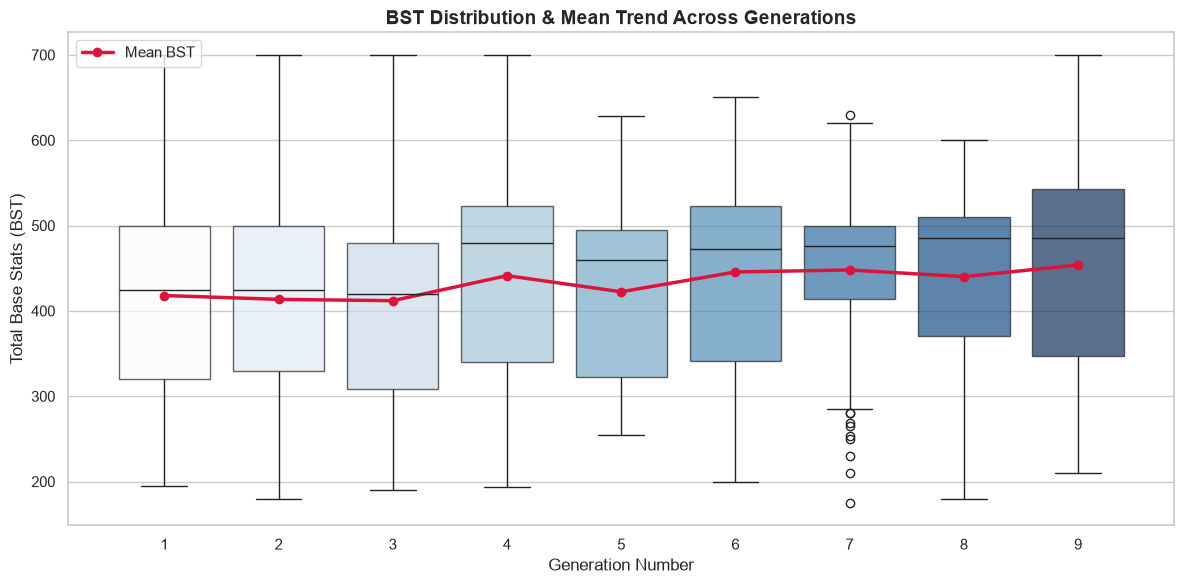

In [20]:
# Code for BST vs. Generation Number
plt.figure(figsize=(12, 6))

df_standard = df[(df['is_legendary'] == False) & (df['is_mythical'] == False)]

sns.boxplot(
    data=df_standard, 
    x='gen_num', 
    y='bst', 
    hue='gen_num',
    palette='Blues',
    legend=False,
    boxprops=dict(alpha=0.7),
    showfliers=True
)

mean_bst = df_standard.groupby('gen_num')['bst'].mean().reset_index()
plt.plot(
    mean_bst.index, 
    mean_bst['bst'], 
    color='crimson', 
    marker='o', 
    linewidth=2.5, 
    label='Mean BST'
)

plt.title('BST Distribution & Mean Trend Across Generations', fontsize=14, fontweight='bold')
plt.xlabel('Generation Number', fontsize=12)
plt.ylabel('Total Base Stats (BST)', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

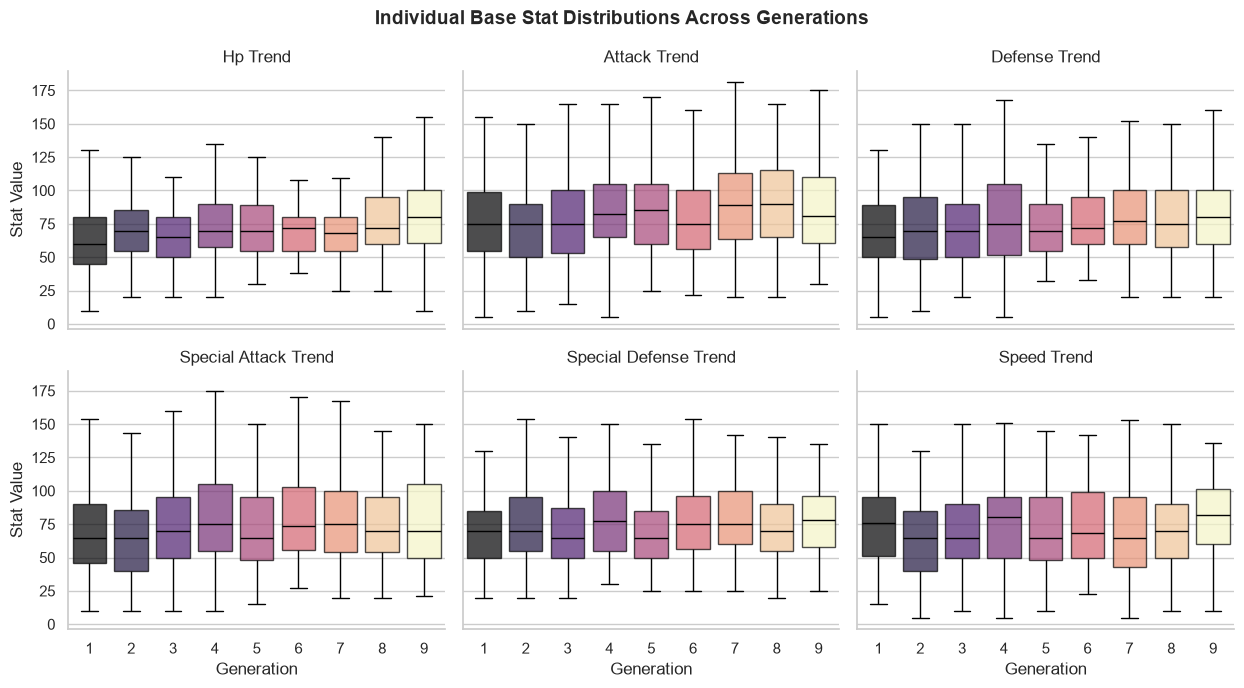

In [16]:
# Code for Individual Stats vs Generation Number
g = sns.catplot(
    data=df_melted,
    x='gen_num',
    y='stat_value',
    col='stat_type',
    col_wrap=3,
    kind='box',
    hue='gen_num',
    palette='magma',
    legend=False,
    height=3.5,
    aspect=1.2,
    boxprops=dict(alpha=0.7),
    showfliers=False,
)

g.set_axis_labels('Generation', 'Stat Value')
g.set_titles(col_template='{col_name} Trend')
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle(
    'Individual Base Stat Distributions Across Generations',
    fontsize=14,
    fontweight='bold',
)

plt.tight_layout()
plt.show()

### Conclusion

When we look at the 